## 4. Outlier Detection

In this task, we aim to identify unusual patterns or potential data errors in key COVID-19 indicators. Outliers can signal important events such as reporting anomalies, sudden outbreaks, or data quality issues. Detecting and understanding these outliers is critical for ensuring the robustness of predictive models and uncovering meaningful deviations in healthcare strain.

We apply statistical techniques such as the Interquartile Range (IQR) method and Z-score thresholds, and use visualizations like box plots and time series plots to highlight abnormalities in variables such as:
- `new_cases`
- `new_deaths`
- `icu_patients`
- `hosp_patients`


In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import zscore

In [3]:
df = pd.read_csv("owid_covid_data_us_subset.csv")

# Convert date to datetime format
df['date'] = pd.to_datetime(df['date'])

# Forward fill and drop missing values in relevant columns
df.ffill(inplace=True)
df.dropna(subset=['new_cases', 'new_deaths', 'icu_patients', 'hosp_patients'], inplace=True)

# Quick look
df[['date', 'new_cases', 'new_deaths', 'icu_patients', 'hosp_patients']].head()

,date,new_cases,new_deaths,icu_patients,hosp_patients
0,2020-07-21,60012.0,932.0,11458.0,42195.0
1,2020-07-22,58519.0,867.0,12487.0,46107.0
2,2020-07-23,63336.0,1193.0,13916.0,47834.0
3,2020-07-24,72416.0,1191.0,13627.0,46748.0
4,2020-07-25,73142.0,1254.0,14402.0,51831.0


### IQR-Based Outlier Detection

In [4]:
def detect_iqr_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = series[(series < lower_bound) | (series > upper_bound)]
    return outliers, lower_bound, upper_bound

columns_to_check = ['new_cases', 'new_deaths', 'icu_patients', 'hosp_patients']

for col in columns_to_check:
    outliers, lower, upper = detect_iqr_outliers(df[col])
    print(f"\n {col} — {len(outliers)} outliers")
    print(f"   IQR Range: {lower:.2f} to {upper:.2f}")


 new_cases — 52 outliers
   IQR Range: -132271.62 to 280435.38

 new_deaths — 47 outliers
   IQR Range: -1637.62 to 3217.38

 icu_patients — 0 outliers
   IQR Range: -14017.12 to 31507.88

 hosp_patients — 87 outliers
   IQR Range: -24568.38 to 100512.62


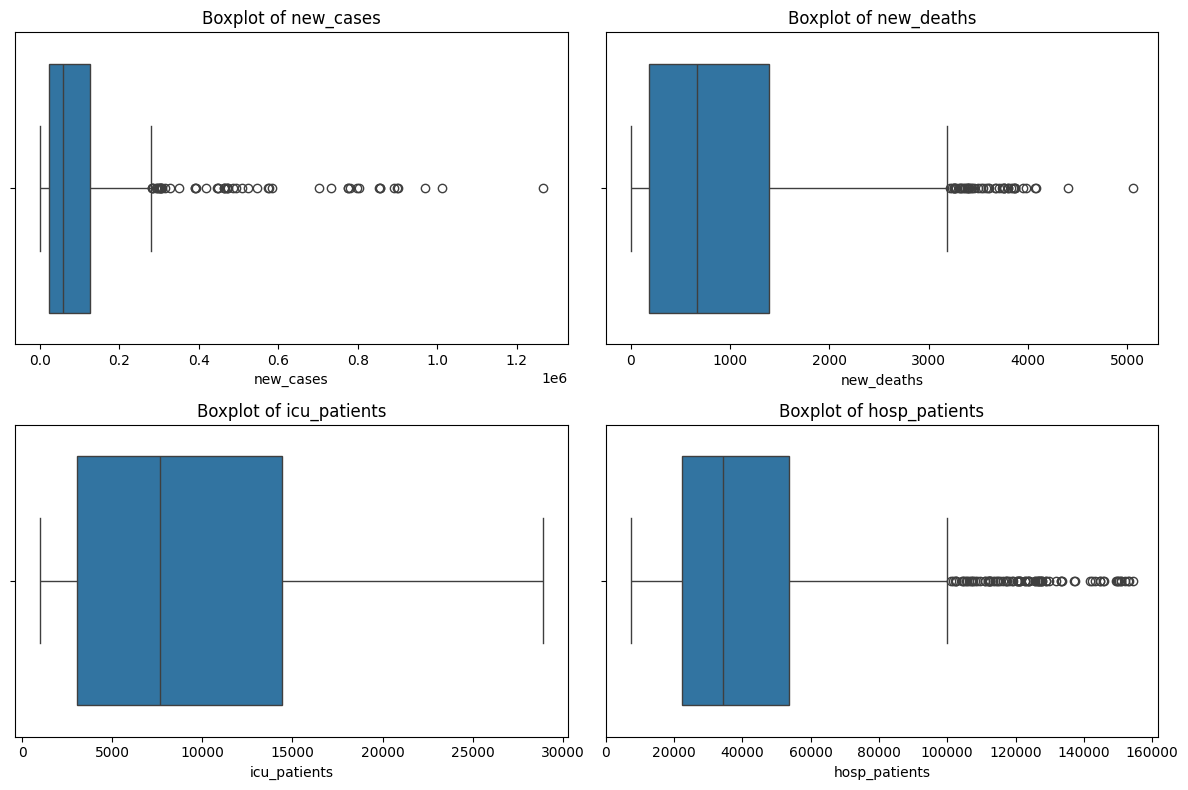

In [5]:
plt.figure(figsize=(12, 8))

for i, col in enumerate(columns_to_check, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()


### Z-Score–Based Outlier Detection

In [ ]:
# Applies Z-score for numeric cols
z_scores = df[columns_to_check].apply(zscore)

# Flag outliers (z-score > 3 or < -3)
z_outlier_flags = (np.abs(z_scores) > 3)

# Counts the outliers for each column
for col in columns_to_check:
    outlier_count = z_outlier_flags[col].sum()
    print(f" {col} — {outlier_count} Z-score outliers")

 new_cases — 22 Z-score outliers
 new_deaths — 8 Z-score outliers
 icu_patients — 0 Z-score outliers
 hosp_patients — 17 Z-score outliers


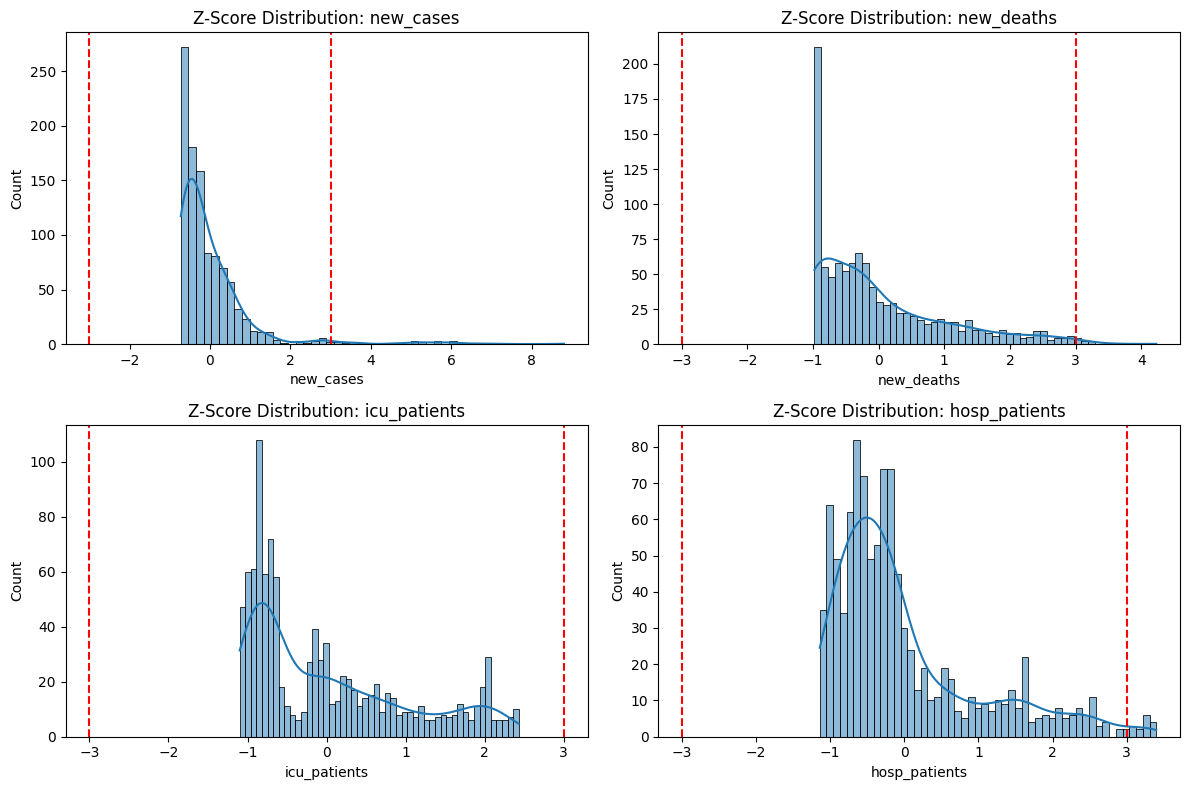

In [8]:
plt.figure(figsize=(12, 8))

for i, col in enumerate(columns_to_check, 1):
    plt.subplot(2, 2, i)
    sns.histplot(z_scores[col], bins=50, kde=True)
    plt.axvline(3, color='red', linestyle='--')
    plt.axvline(-3, color='red', linestyle='--')
    plt.title(f'Z-Score Distribution: {col}')

plt.tight_layout()
plt.show()
